Macierz kosztów k(i,j):
[[39 29 15 43  8 21 39 19 23 11]
 [11 24 36 40 24  3 22  2 24 44]
 [30 38  2 21 33 12 22 44 25 49]
 [27 42 28 16 15 47 44  3 37  7]
 [21  9 39 18  4 25 14 50  9 26]
 [ 2 20 28 47  7 44  8 47 35 14]
 [17 36 50 40  4  2  6 42  4 29]
 [18 26 44 34 10 36 14 31 48 15]
 [ 8 14 23 40 21 16 45 18 47 24]
 [26 25 45 41 29 15 45  1 25  7]]
------------------------------
Najlepsze rozwiązanie (przypisanie): [4 5 2 7 3 1 8 6 0 9]
Minimalny koszt: 87.0


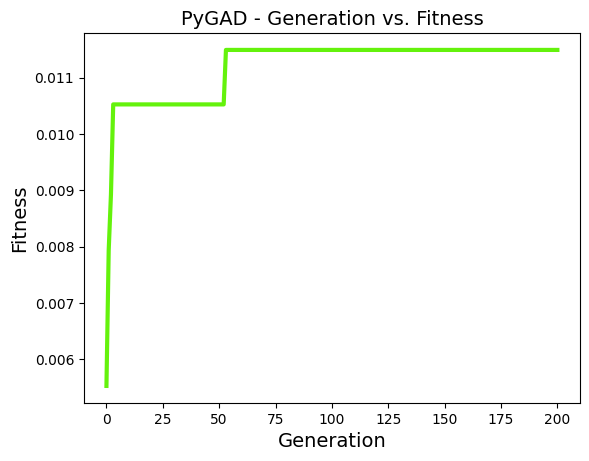

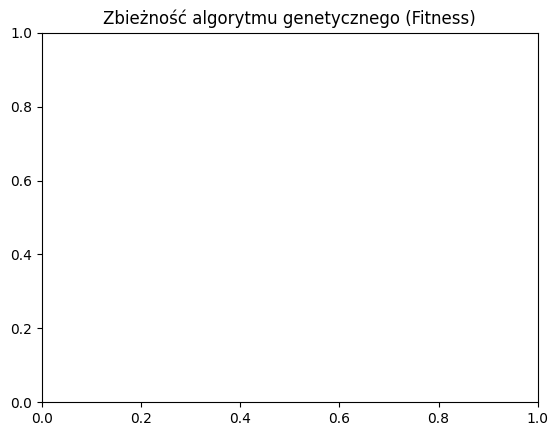

In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

# 1. Konfiguracja problemu
N =10 #liczba zadań i wykonawców
SEED = 42 #ustawienie ziarna losowości dla powtarzalności wyników

# Generacja macierzy kosztów (czasów wykonania zadań przez wykonawców)
np.random.seed(SEED)
cost_matrix = np.random.randint(1, 51, size=(N, N))

print("Macierz kosztów k(i,j):")
print(cost_matrix)

# 2. Definicja funkcji dopasowania (fitness function)
#celem jest MINIMALIZACJA sumy kosztów, więc fitness będzie odwrotnością tej sumy 
#PyGAD domyślnie MAKSYMALIZUJE firness
#Dlategpo zwracamy 1/ suma_kosztów
def fitness_func(ga_instance, solution, solution_idx):
    total_cost = 0
    for task_idx, worker_idx in enumerate(solution):
        total_cost += cost_matrix[task_idx, int(worker_idx)]

        #Firness musi być dodatni i rosnąć gdy koszt maleje
    fitness = 1.0 / total_cost
    return fitness

#3. Konfiguracja algorytmu genetycznego
ga_instance = pygad.GA(num_generations=200, #liczba pokoleń
                       num_parents_mating=10, #liczba rodziców do krzyżowania
                       fitness_func=fitness_func, #funkcja dopasowania / celu
                       sol_per_pop=50, #liczba rozwiązań w populacji - wilkosc populacji
                       num_genes=N, #liczba genów (zadań)
                       
                       #Geny to indeksy wykonawców, więc muszą być całkowite i mieścić się w zakresie [0, N-1]
                       gene_space=list(range(N)), #dozwolone wartości genów (indeksy wykonawców)
                       gene_type=int,

                       #Kluczowe dla Zagadnienia Przydziału:
                       parent_selection_type="sss", #selekcja rodziców - selekcja turniejowa Steady State Selection
                       keep_parents=2, #liczba rodziców do zachowania bez zmian w następnej generacji

                       crossover_type="single_point", #typ krzyżowania - jednopunktowe

                       #Uzywamy mutacji, ktora zmienia geny miejscami aby zachowac permutacje (kazdy wykonawca raz)
                       mutation_type="swap", 
                       mutation_probability=0.1,

                       #Blokada powtorzern w chromosomie (kazdy wykonawaca tylko raz)
                       allow_duplicate_genes=False
)

#4. Uruchomienie algorytmu genetycznego
ga_instance.run()

#5.Podsumowanie wynikow 
solution, solution_fitness, solution_idx = ga_instance.best_solution()
best_cost = 1.0 / solution_fitness

print("-"*30)
print(f"Najlepsze rozwiązanie (przypisanie): {solution}")
print(f"Minimalny koszt: {best_cost}")

# 6. Wykres zbieżności
# Metoda plot_fitness() zwraca obiekt figury, jeśli chcemy go modyfikować
ga_instance.plot_fitness()
plt.title("Zbieżność algorytmu genetycznego (Fitness)")
plt.xlabel("Pokolenie")
plt.ylabel("Wartość dopasowania")
plt.grid(True) #Dodanie siatki pomaga w odczycie
plt.show()
